In [2]:
import numpy as np
import pandas as pd
df = pd.read_csv("/Users/serhatguldogan/Library/CloudStorage/OneDrive-KocUniversitesi/Project_/RAW DATA/BTC_1sec.csv")

df.head()



,Unnamed: 0,system_time,midpoint,spread,buys,sells,bids_distance_0,bids_distance_1,bids_distance_2,bids_distance_3,...,asks_market_notional_5,asks_market_notional_6,asks_market_notional_7,asks_market_notional_8,asks_market_notional_9,asks_market_notional_10,asks_market_notional_11,asks_market_notional_12,asks_market_notional_13,asks_market_notional_14
0,0,2021-04-07 11:32:42.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,2021-04-07 11:32:43.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,2021-04-07 11:32:44.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,2021-04-07 11:32:45.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,2021-04-07 11:32:46.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
arr=df.columns

In [4]:
# Remove leading/trailing whitespace and newlines from all column names

df.columns = [col.strip() for col in df.columns]
print(df.columns)  # Check the cleaned column names

Index(['Unnamed: 0', 'system_time', 'midpoint', 'spread', 'buys', 'sells',
       'bids_distance_0', 'bids_distance_1', 'bids_distance_2',
       'bids_distance_3',
       ...
       'asks_market_notional_5', 'asks_market_notional_6',
       'asks_market_notional_7', 'asks_market_notional_8',
       'asks_market_notional_9', 'asks_market_notional_10',
       'asks_market_notional_11', 'asks_market_notional_12',
       'asks_market_notional_13', 'asks_market_notional_14'],
      dtype='object', length=156)


In [5]:

np.array(df.columns)

bids_listed = np.array(df[[f"bids_notional_{c}" for c in range(15)]])
bids_volume = np.sum(bids_listed , axis = 1)


In [6]:
asks_listed = np.array(df[[f"asks_notional_{c}" for c in range(15)]])
asks_volume = np.sum(asks_listed, axis=1)

In [7]:
bids_volume + asks_volume

array([795004.72250366, 795004.72250366, 795004.72250366, ...,
       485743.75895691, 368204.32170868, 603862.77484441])

In [8]:
volumes = bids_volume + asks_volume

In [9]:
len(volumes)

1030728

In [10]:

print(volumes)


[795004.72250366 795004.72250366 795004.72250366 ... 485743.75895691
 368204.32170868 603862.77484441]


In [11]:
arr2 = np.copy(volumes)

In [12]:
df = df.drop(df.columns[0],axis=1)
df = df.drop(df.columns[4:],axis=1)
l = list(df.midpoint)
index_set=[]
for i in range(1,len(l)):
    if l[i-1]!=l[i]:
        index_set.append(i)

mask = [0]
for i in range(1,len(l)):
    if l[i-1]!=l[i]:
        mask.append(1)
    else: 
        mask.append(0)

m = np.array(mask)


In [13]:
volumes_in_price_changes = arr2[m==1]

In [14]:
volume_counts_new = {}
for volume in volumes_in_price_changes:
    if volume in volume_counts_new:
        volume_counts_new[volume] += 1
    else:
        volume_counts_new[volume] = 1


In [15]:
import matplotlib.pyplot as plt

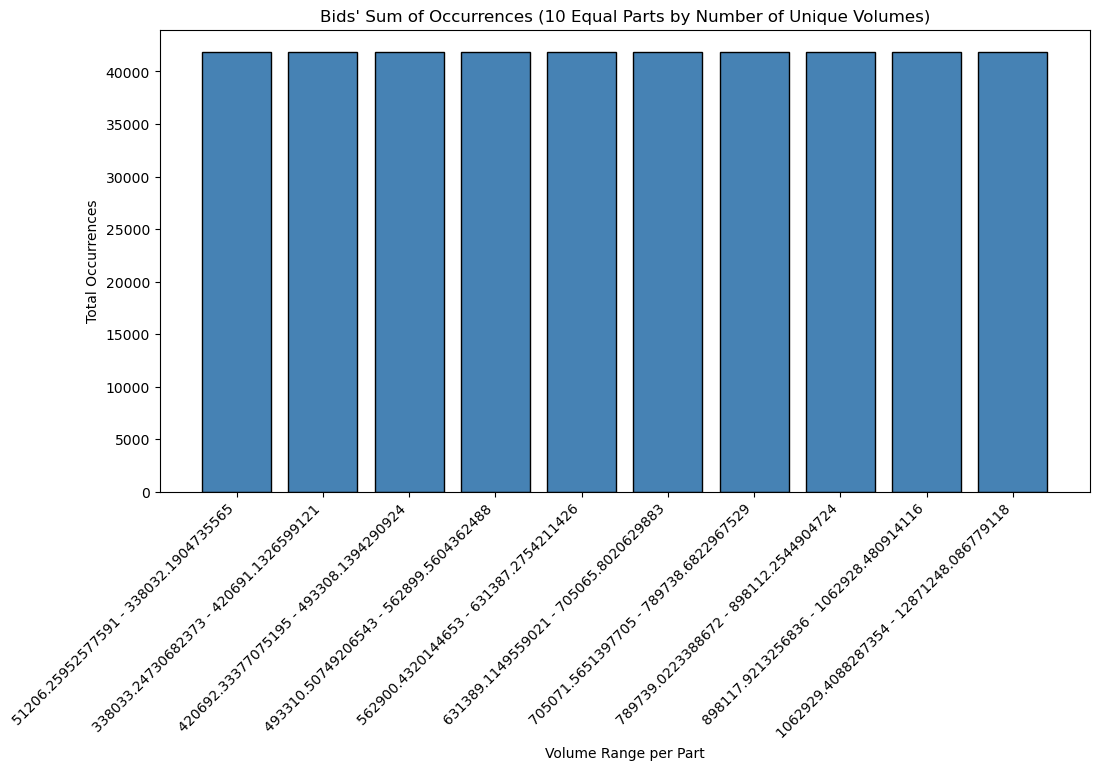

In [16]:
sorted_volumes = sorted(volume_counts_new.keys())

# 2. Split the sorted volumes into 10 equal parts (equal number of keys per part)
# np.array_split handles the division even if the total length isn't perfectly divisible by 10
chunks = np.array_split(sorted_volumes, 10)

bin_sums = []
bin_labels = []

# 3. Iterate through each part, sum the occurrences, and create labels
for chunk in chunks:
    if len(chunk) == 0:
        continue
        
    # Sum the values (occurrences) for every volume key in this specific chunk
    total_occurrences = sum(volume_counts_new[vol] for vol in chunk)
    bin_sums.append(total_occurrences)
    
    # Create a label showing the range of this chunk (min volume to max volume)
    # If your volumes are long floats, you can wrap them in round(), e.g., round(chunk[0], 2)
    label = f"{chunk[0]} - {chunk[-1]}"
    bin_labels.append(label)

# 4. Plot the results as a bar chart
plt.figure(figsize=(12, 6))
plt.bar(bin_labels, bin_sums, color='steelblue', edgecolor='black')

plt.title("Bids' Sum of Occurrences (10 Equal Parts by Number of Unique Volumes)")
plt.xlabel("Volume Range per Part")
plt.ylabel("Total Occurrences")

# Rotate the x-axis labels so they don't overlap
plt.xticks(rotation=45, ha='right') 

# Adjust layout so the angled labels fit perfectly

plt.show()

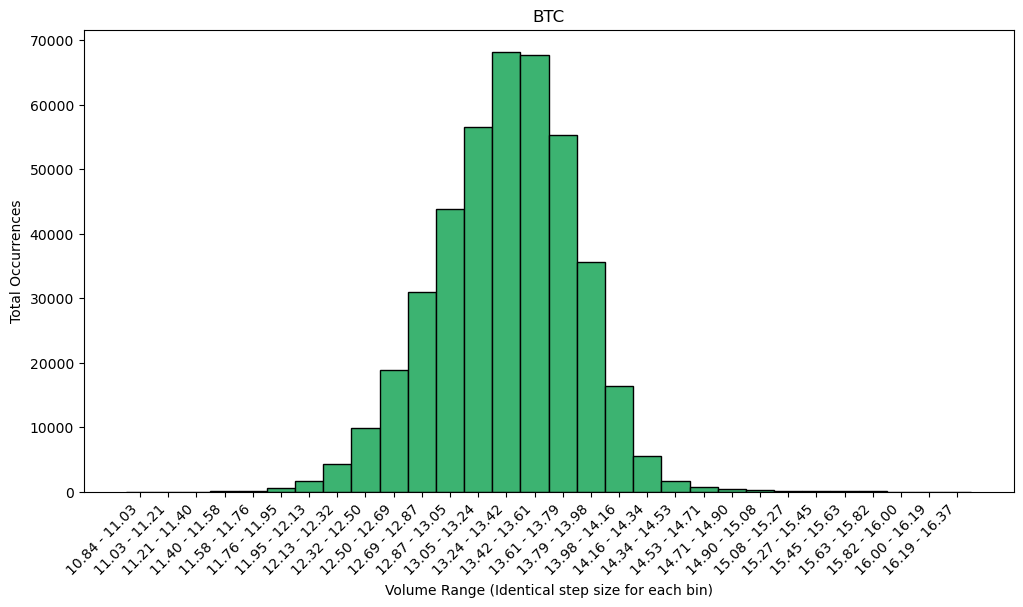

In [30]:
volumes_ = list(np.log(list(volume_counts_new.keys())))
counts = list(volume_counts_new.values())

# 2. Automatically create 10 equal-width bins and sum the counts
# The 'weights' parameter ensures it sums your occurrences instead of just counting the unique keys
bin_sums, bin_edges = np.histogram(volumes_, bins=30, weights=counts)

# 3. Create readable labels for each of the 10 bins
# We round to 2 decimal places for cleaner visual formatting on the chart
bin_labels = [f"{bin_edges[i]:.2f} - {bin_edges[i+1]:.2f}" for i in range(30)]

# 4. Plot the histogram using a bar chart
plt.figure(figsize=(12, 6))

# width=1.0 makes the bars touch, which is the standard look for a continuous histogram
plt.bar(bin_labels, bin_sums, width=1.0, color='mediumseagreen', edgecolor='black')

plt.title("BTC")
plt.xlabel("Volume Range (Identical step size for each bin)")
plt.ylabel("Total Occurrences")

# Rotate the x-axis labels so they are readable
plt.xticks(rotation=45, ha='right') 

# Adjust layout to prevent labels from being cut off

plt.show()

In [24]:
mean = np.mean(np.log(list(volume_counts_new.keys())))
std = np.std(np.log(list(volume_counts_new.values())))

In [25]:
print(mean,std)

13.329567797401769 0.0015146064211376987


Then, $$f_X(x) = \frac{1}{x \sigma \sqrt{2\pi}} \exp(\frac{-(\ln(x) - \mu)^2}{2 \sigma ^2})$$

In [20]:
print(np.log(volumes_in_price_changes))

[12.17612449 13.08086344 13.38751254 ... 12.99928064 12.90380443
 13.31110226]


In [21]:
len(volumes)

1030728

In [22]:
np.savetxt("volumes_and_mask", np.stack((volumes,mask), axis = 1), fmt = "%f,%d")